In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import matplotlib.pyplot as plt
import polars as pl

import clustering

# Hierarchical Clustering of Asteroids

Using the distance thresholds determined in `parameter_sweep.ipynb`, hierarchical clustering is performed to find asteroid families in each zone. These zones are defined in "Milani et al. (2014). Asteroid families classification: Exploiting very large datasets" and are split by semi-major axis and inclination.

| Zone    | Sine of Inclination | Semimajor Axis Range | Distance Threshold |
|---------|---------------------|----------------------|--------------------|
| 1       | all                 | 1.600 - 2.000        | 0.0021             |
| 2 low   | < 0.3               | 2.000 - 2.500        | 0.0019             |
| 2 high  | > 0.3               | 2.000 - 2.500        | 0.0050             |
| 3 low   | < 0.3               | 2.500 - 2.825        | 0.0014             |
| 3 high  | > 0.3               | 2.500 - 2.825        | 0.0045             |
| 4 low   | < 0.3               | 2.825 - 3.278        | 0.0016             |
| 4 high  | > 0.3               | 2.825 - 3.278        | 0.0030             |
| 5       | all                 | 3.278 - 3.700        | 0.0045             |
| 6       | all                 | 3.700 - 4.000        | 0.0018             |


## Zone 1

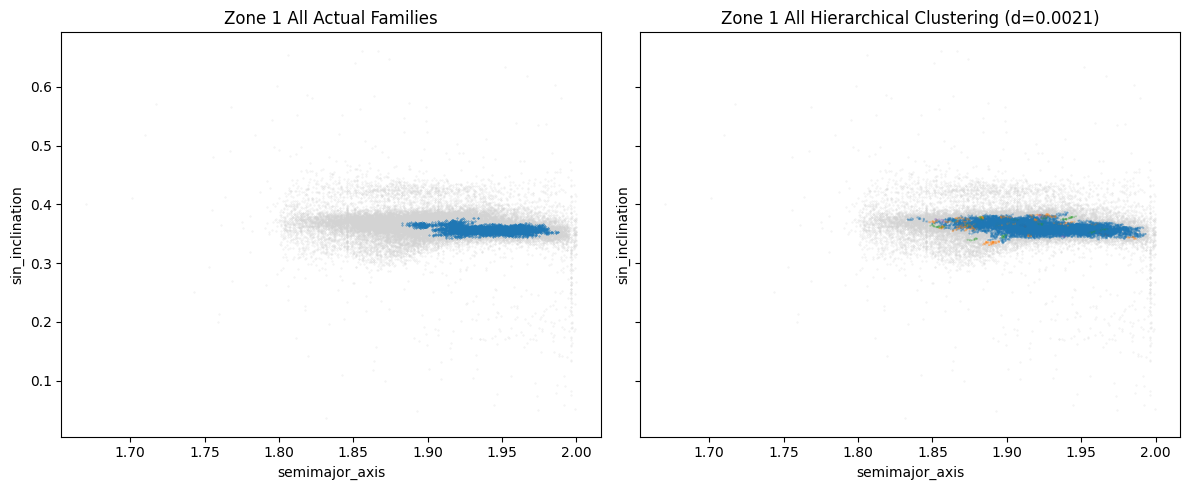

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
434,10874,97.002924,36.610263


In [37]:
z1_summary = clustering.clustering_comparison(1, "all", 0.0021)
z1_summary

Hierarchical clustering is able to find the complete family 434 Hungaria in Zone 1, but with quite a low purity of 37%, including many background asteroids. This is clear in the size of the main cluster, being much larger than the size of the actual family. 

## Zone 2

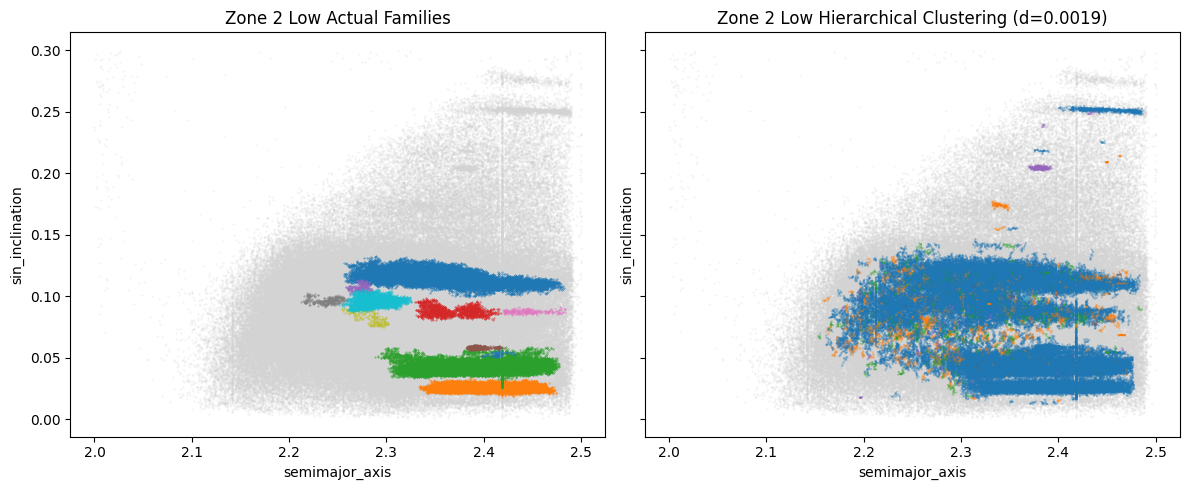

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
302,830,100.0,59.759036
4,27492,97.207647,58.627964
135,60648,98.350855,40.415183
163,5692,98.847087,28.619115
2076,11432,98.742666,20.608817


In [38]:
z2_low_summary = clustering.clustering_comparison(2, "low", 0.0019)
z2_low_summary

Hierarchical clustering is able to find 5 complete families in Zone 2 Low, but with quite poor purities. This is again evident in the plots above, showing much larger, messier clusters.

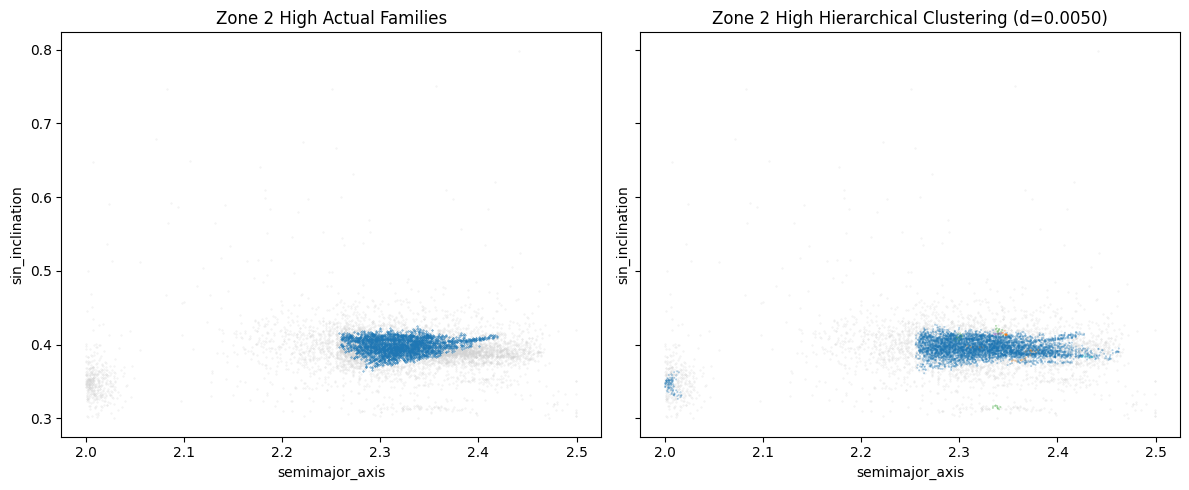

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
25,4899,96.001454,53.908961


In [39]:
z2_high_summary = clustering.clustering_comparison(2, "high", 0.0050)
z2_high_summary

Hierarchical clustering is able to find the complete family 25 Phocaea in Zone 2 High, again with a lower purity of 54%.

## Zone 3

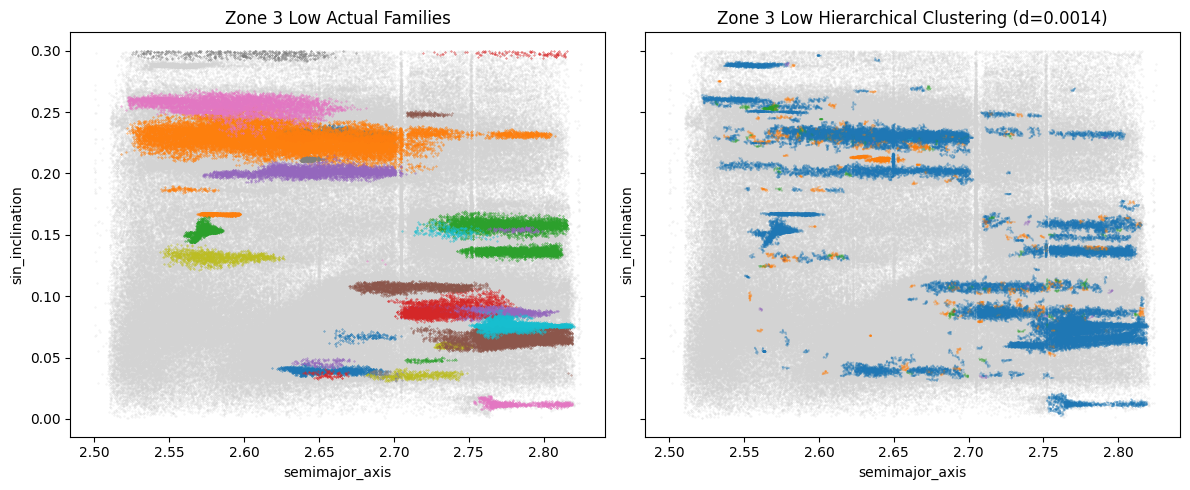

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
396,1746,99.571865,93.241695
1547,1975,98.543417,89.063291
3815,2311,99.64557,85.15794
606,1378,100.0,84.179971
1128,1136,95.12987,77.376761
1726,6081,98.046791,75.119224
3,8781,97.232472,48.012755


In [40]:
z3_low_summary = clustering.clustering_comparison(3, "low", 0.0014)
z3_low_summary

Hierarchical clustering does quite well in Zone 3 Low, finding 7 complete families, 4 of whom have purity above 80% and 6 of whom have purity above 70%. Most of the high purity complete clusters are similarly medium sized, around 1000-2000 asteroids. This could point at hierarchical clustering performing better on these mid sized families, which are more common in this zone.

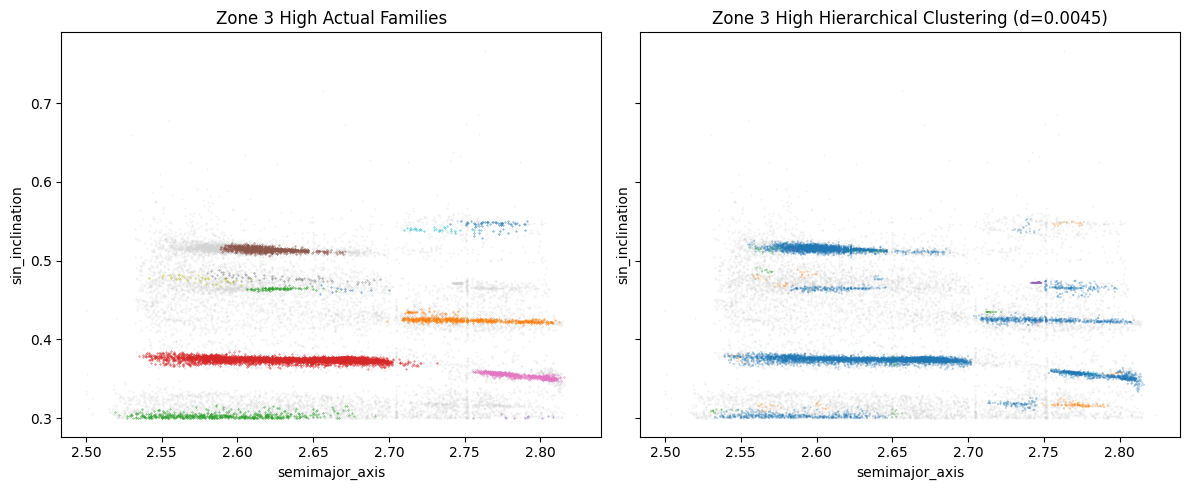

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
480,4522,95.341207,96.3954
148,614,98.638132,82.57329
1222,749,99.453552,72.897196
116763,219,95.0,43.378995


In [41]:
z3_high_summary = clustering.clustering_comparison(3, "high", 0.0045)
z3_high_summary

Hierarchical clustering similarly does quite well in Zone 3 High, finding 4 complete families, one of which exceeds 95% purity. This zone does appear to be easier for finding families, as each family sits nicely within its own inclination band.

## Zone 4 Low

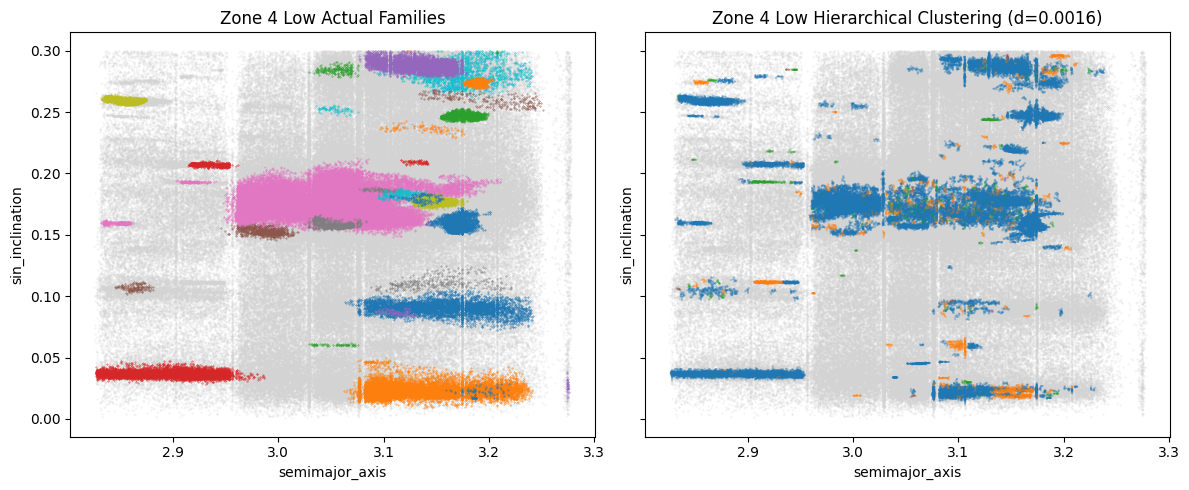

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
618,658,99.29078,85.106383
3330,4745,95.303939,76.986301
18405,494,98.691099,76.315789
1189,284,97.596154,71.478873
778,3726,97.969731,71.2292
293,3069,99.014778,65.493646


In [42]:
z4_low_summary = clustering.clustering_comparison(4, "low", 0.0016)
z4_low_summary

Hierarchical clustering does fairly well in Zone 4 Low, finding 6 complete families, of varying sizes. Families under 1000 asteroids and families around 4000 asteroids were both found with purity above 70%. Comparing the two plots, this distance threshold seems to have selected for the more densely packed families, unable to link the families that are more spread apart.

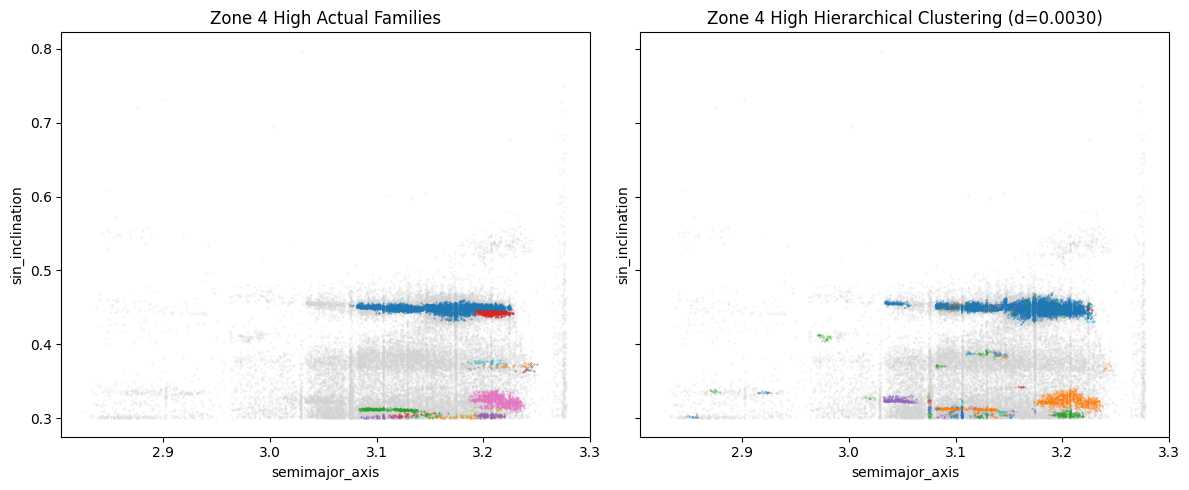

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
780,369,98.161765,72.357724
1303,1086,95.622435,64.364641
69559,272,100.0,51.470588


In [43]:
z4_high_summary = clustering.clustering_comparison(4, "high", 0.0030)
z4_high_summary

In Zone 4 High, hierarchical clustering finds 3 complete families, with varying levels of purity. Compared to Zone 3 High, families in this zone are more closely packed, with varying densities within families, making it more difficult for hierarchical clustering to identify.

## Zone 5

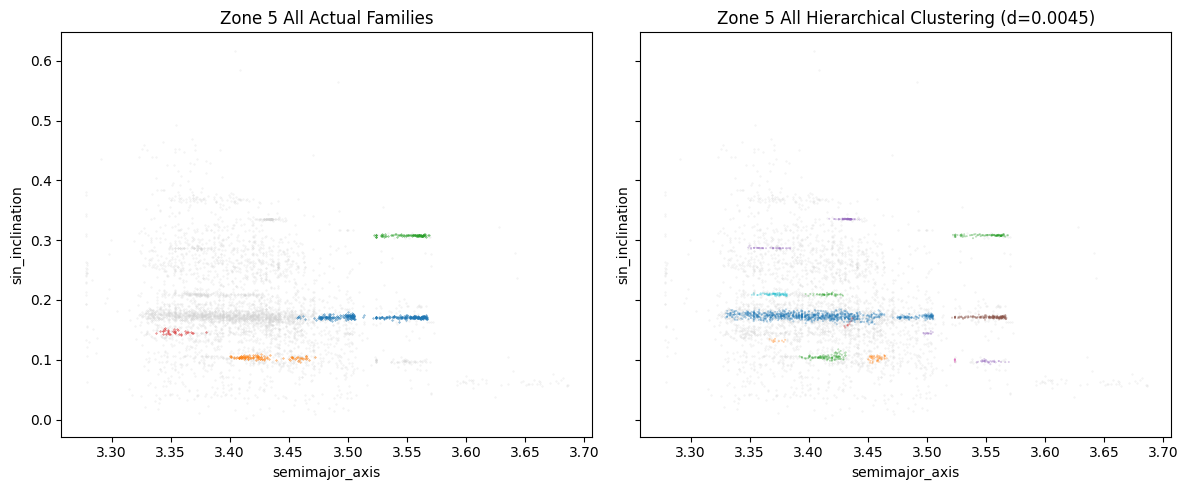

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
909,97,98.947368,96.907216


In [44]:
z5_summary = clustering.clustering_comparison(5, "all", 0.0045)
z5_summary

In Zone 5, hierarchical is only able to find one of the families completely, but with a very high purity of 97%. This again speaks to the varying density of families in this zone making it difficult for hierarchical clustering, as hierarchial clustering is based on a single distance threshold.

## Zone 6

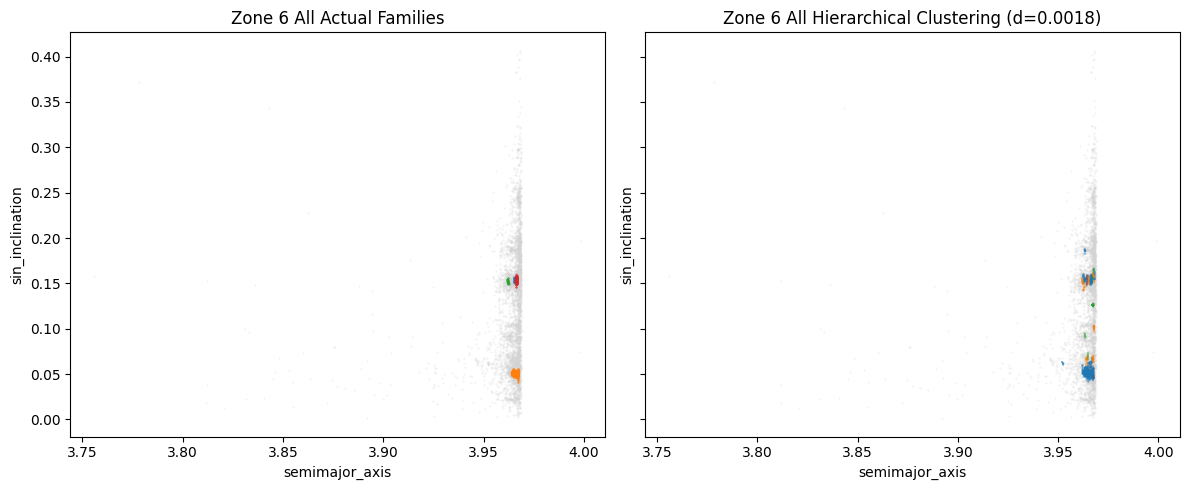

main_family,cluster_size,family_completeness,cluster_purity
i64,u32,f64,f64
6124,152,95.070423,88.815789
1911,1573,98.995434,68.912905


In [45]:
z6_summary = clustering.clustering_comparison(6, "all", 0.0018)
z6_summary

Hierarchical clustering was able to find 2 complete families in Zone 6, needing a smaller distance threshold as all asteroids in Zone 6 sit in a narrow band.

## Summary

In total, hierarchical clustering was able to find 30 complete families across all zones, with an average purity of 67.8%. Nine of these clusters had purity above 80% and 2 were able to meet the benchmark of 95% purity.

Total number of complete clusters found: 30
Average purity of all complete clusters: 67.8%
Number of complete clusters with purity >= 80%: 9
Number of complete clusters with purity >= 95%: 2


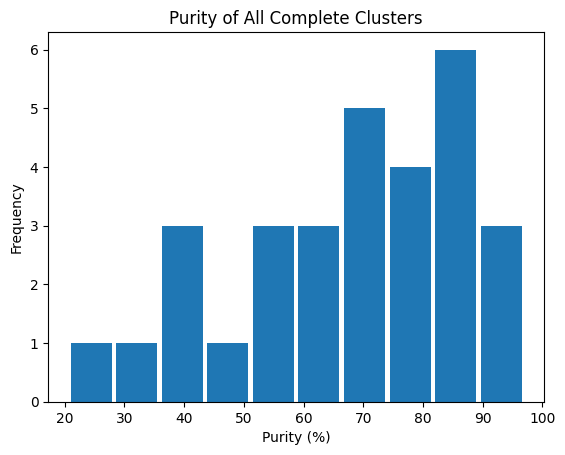

In [51]:
all_complete = pl.concat([z1_summary, z2_low_summary, z2_high_summary, z3_low_summary, z3_high_summary, z4_low_summary, z4_high_summary, z5_summary, z6_summary])

print(f"Total number of complete clusters found: {len(all_complete)}")
print(f"Average purity of all complete clusters: {all_complete['cluster_purity'].mean():.1f}%")
print(f"Number of complete clusters with purity >= 80%: {len(all_complete.filter(pl.col('cluster_purity') >= 80))}")
print(f"Number of complete clusters with purity >= 95%: {len(all_complete.filter(pl.col('cluster_purity') >= 95))}")

plt.hist(all_complete["cluster_purity"], rwidth=0.9)
plt.title("Purity of All Complete Clusters")
plt.xlabel("Purity (%)")
plt.ylabel("Frequency")
plt.show()

Below shows all 30 complete clusters found, plotted against semimajor axis and sine of inclination.

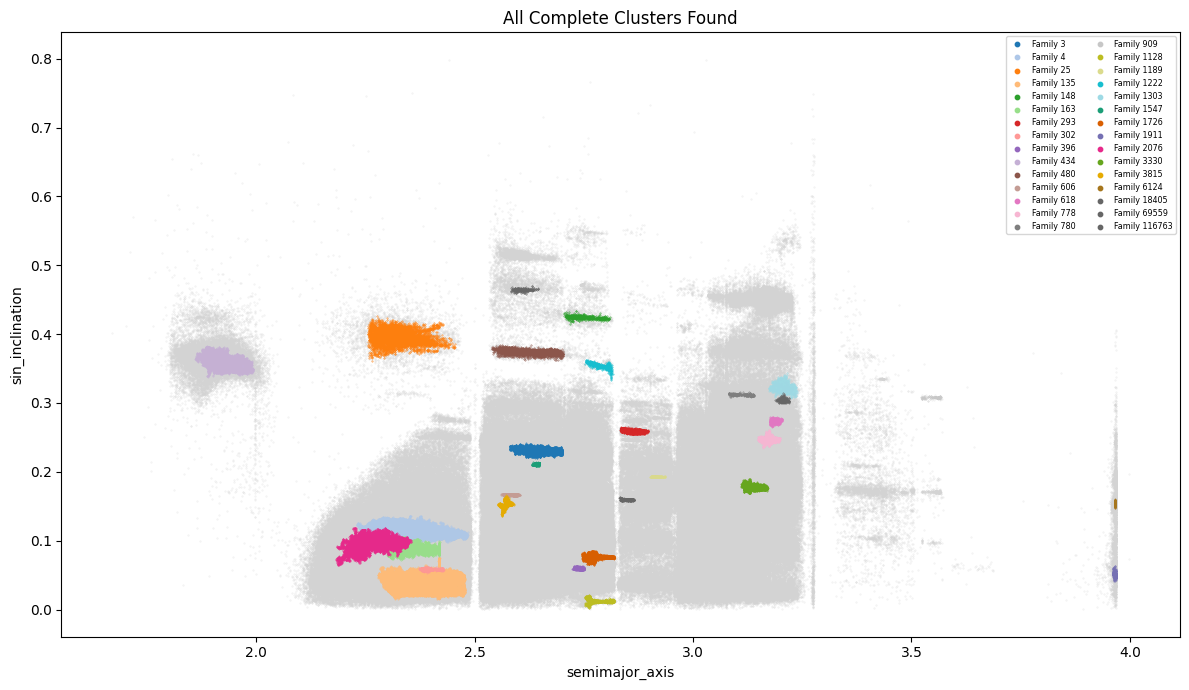

In [62]:
complete = clustering.find_all_complete_clusters()